In [4]:
import pandas as pd
import psycopg
import os
from dotenv import load_dotenv
from db import JDBC_URL, conn_string

load_dotenv()

PG_HOST     = os.environ.get("DB_HOST")
PG_PORT     = os.environ.get("DB_PORT")
PG_DB       = os.environ.get("DB_DATABASE")
PG_USER     = os.environ.get("DB_USERNAME")
PG_PASSWORD = os.environ.get("DB_PASSWORD")

conn_string = f"host={PG_HOST} port={PG_PORT} dbname={PG_DB} user={PG_USER} password={PG_PASSWORD}"

conn = psycopg.connect(conn_string)
df = pd.read_sql('SELECT * FROM public_gold.fact_rates LIMIT 100', conn)
df.head()

C:\Users\Tanel\AppData\Local\Temp\ipykernel_50644\590923641.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql('SELECT * FROM public_gold.fact_rates LIMIT 100', conn)


,date_key,curr_base,currency,rate
0,20260319070316,TWD,DZD,4.150865
1,20260319070316,TWD,GIP,0.023367
2,20260319070316,TWD,MWK,54.490015
3,20260319070316,TWD,HNL,0.832620
4,20260319070316,TWD,MXN,0.556139


In [9]:
query = """
SELECT d.date, f.curr_base, f.currency, f.rate
FROM public_gold.fact_rates f
JOIN public_gold.dim_date d ON f.date_key = d.date_key
LIMIT 1000
"""
df = pd.read_sql(query, conn)
# df.head()
print(len(df))
df

1000


C:\Users\Tanel\AppData\Local\Temp\ipykernel_50644\767658636.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,date,curr_base,currency,rate
0,2026-03-19 19:20:16,TWD,DZD,4.150865
1,2026-03-19 19:20:16,TWD,GIP,0.023367
2,2026-03-19 19:20:16,TWD,MWK,54.490015
3,2026-03-19 19:20:16,TWD,HNL,0.832620
4,2026-03-19 19:20:16,TWD,MXN,0.556139
...,...,...,...,...
995,2026-03-19 19:20:04,ANG,RUB,47.738813
996,2026-03-19 19:20:04,ANG,LYD,3.539747
997,2026-03-19 19:20:04,ANG,MOP,4.475726
998,2026-03-19 19:20:04,ANG,MUR,25.800680


,curr_base,currency
0,TWD,DZD
1,TWD,GIP
2,TWD,MWK
3,TWD,HNL
4,TWD,MXN
5,TWD,BWP
6,TWD,LKR
7,TWD,TND
8,TWD,TMT
9,TWD,VND


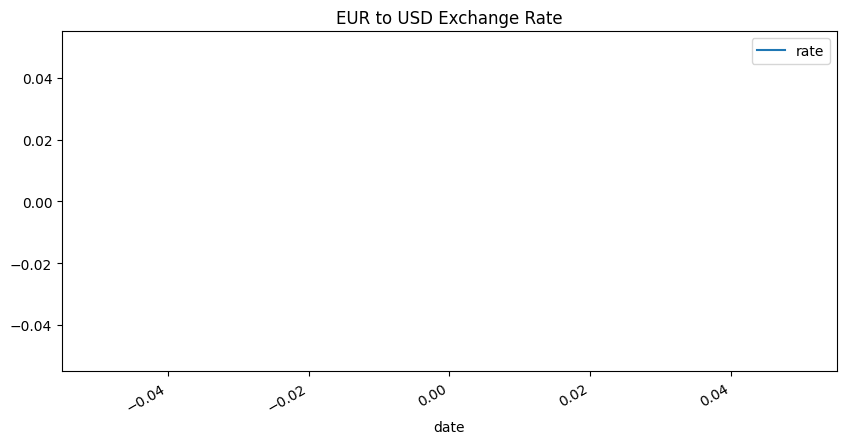

In [12]:
# Example: EUR to USD (adjust based on what you have)
df_pair = df[(df['curr_base'] == 'EUR') & (df['currency'] == 'USD')]

# Plot
df_pair.plot(x='date', y='rate', kind='line', title='EUR to USD Exchange Rate', figsize=(10, 5))


C:\Users\Tanel\AppData\Local\Temp\ipykernel_50644\354930451.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_top = pd.read_sql(query, conn)


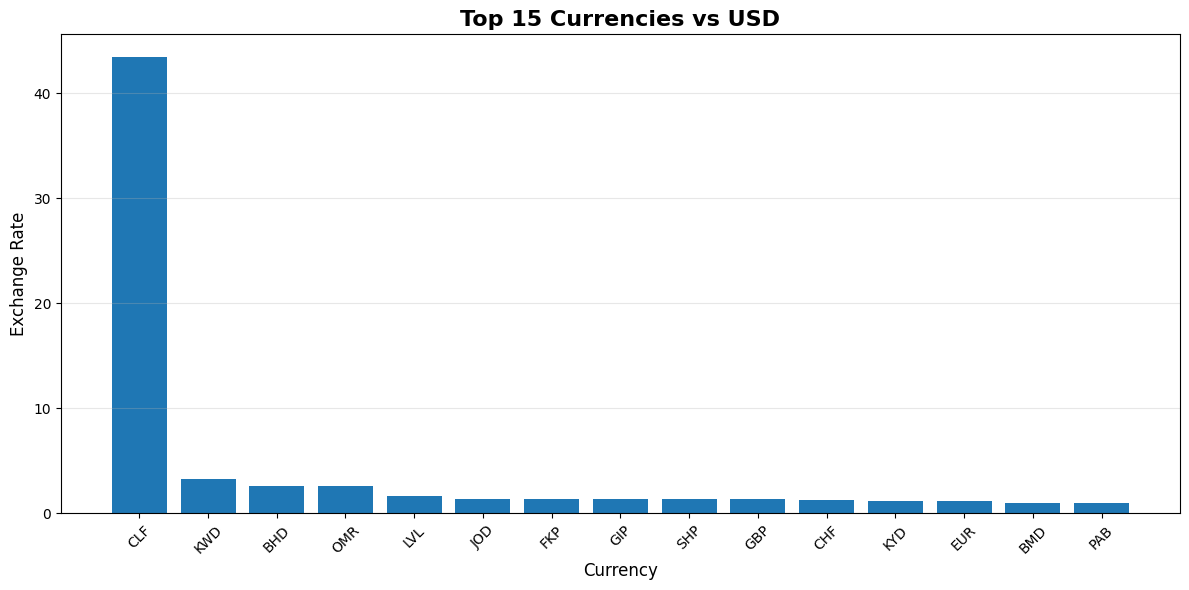

In [21]:
import matplotlib.pyplot as plt
%matplotlib inline

# Get top 15 currencies by rate against USD
query = """
SELECT f.curr_base, AVG(f.rate) as avg_rate
FROM public_gold.fact_rates f
WHERE f.currency = 'USD'
GROUP BY f.curr_base
ORDER BY avg_rate DESC
LIMIT 15
"""
df_top = pd.read_sql(query, conn)

# Create bar chart
plt.figure(figsize=(12, 6))
plt.bar(df_top['curr_base'], df_top['avg_rate'])
plt.title('Top 15 Currencies vs USD', fontsize=16, fontweight='bold')
plt.xlabel('Currency', fontsize=12)
plt.ylabel('Exchange Rate', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()